# QuantWeather-BD 🌦️⚛️
## Quantum Machine Learning-Based Weather Forecasting for Bangladesh

| | |
|---|---|
| **Dataset** | NASA POWER Daily Weather Data (1981–2026), Dhaka, Bangladesh |
| **Model** | Hybrid Variational Quantum Circuit (VQC) + Classical Neural Network |
| **Framework** | PennyLane + PyTorch |
| **Target** | Next-day multi-variable weather prediction |
| **Baselines** | Linear Regression, Random Forest, MLP, LSTM |

---

## ⚙️ Step 0: Install Dependencies

In [1]:
!pip install pennylane pennylane-lightning -q
!pip install torch scikit-learn pandas numpy matplotlib seaborn joblib tqdm scipy -q
print('✅ All packages installed!')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 1.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 27.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 5.6 MB/s eta 0:00:00
✅ All packages installed!


## 📦 Step 1: Import Libraries

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm import tqdm
import time
import joblib
import os

from sklearn.preprocessing import MinMaxScaler, label_binarize
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             confusion_matrix, classification_report,
                             roc_curve, auc, ConfusionMatrixDisplay)
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from scipy import stats

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import pennylane as qml

plt.style.use('seaborn-v0_8')
np.random.seed(42)
torch.manual_seed(42)

device_torch = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Libraries imported successfully.')
print(f'Using device: {device_torch}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Libraries imported successfully.
Using device: cpu


## 🔗 Step 2: Mount Google Drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')
SAVE_DIR = '/content/drive/MyDrive/QuantWeather-BD/'
os.makedirs(SAVE_DIR, exist_ok=True)
print('✅ Google Drive mounted!')

Mounted at /content/drive
✅ Google Drive mounted!


## 📂 Step 3: Load & Clean Dataset

In [4]:
dataset_path = '/content/drive/MyDrive/QuantWeather-BD/Dataset/bangladesh_weather_1981_2026.csv'

df = pd.read_csv(dataset_path, skiprows=14)
df.columns = df.columns.str.strip()
df['DATE'] = pd.to_datetime(dict(year=df['YEAR'], month=df['MO'], day=df['DY']))
df.replace(-999, np.nan, inplace=True)
df = df.sort_values('DATE').reset_index(drop=True)

print(f'Dataset shape: {df.shape}')
print(f'Date range: {df["DATE"].min()} → {df["DATE"].max()}')
print(f'\nMissing values:')
print(df.isnull().sum())
df.head()

Dataset shape: (16570, 10)
Date range: 1981-01-01 00:00:00 → 2026-05-14 00:00:00

Missing values:
YEAR           0
MO             0
DY             0
T2M            3
T2M_MAX        3
T2M_MIN        3
RH2M           3
PRECTOTCORR    3
WS2M           3
DATE           0
dtype: int64


,YEAR,MO,DY,T2M,T2M_MAX,T2M_MIN,RH2M,PRECTOTCORR,WS2M,DATE
0,1981,1,1,18.63,26.32,12.24,55.22,0.00,1.49,1981-01-01
1,1981,1,2,19.06,25.86,13.72,51.12,0.00,0.93,1981-01-02
2,1981,1,3,19.22,25.98,13.49,55.75,0.00,0.90,1981-01-03
3,1981,1,4,19.11,26.09,13.64,53.51,0.00,1.34,1981-01-04
4,1981,1,5,19.87,26.82,13.46,58.67,0.03,1.07,1981-01-05


## 📊 Step 4: Exploratory Data Analysis (EDA)

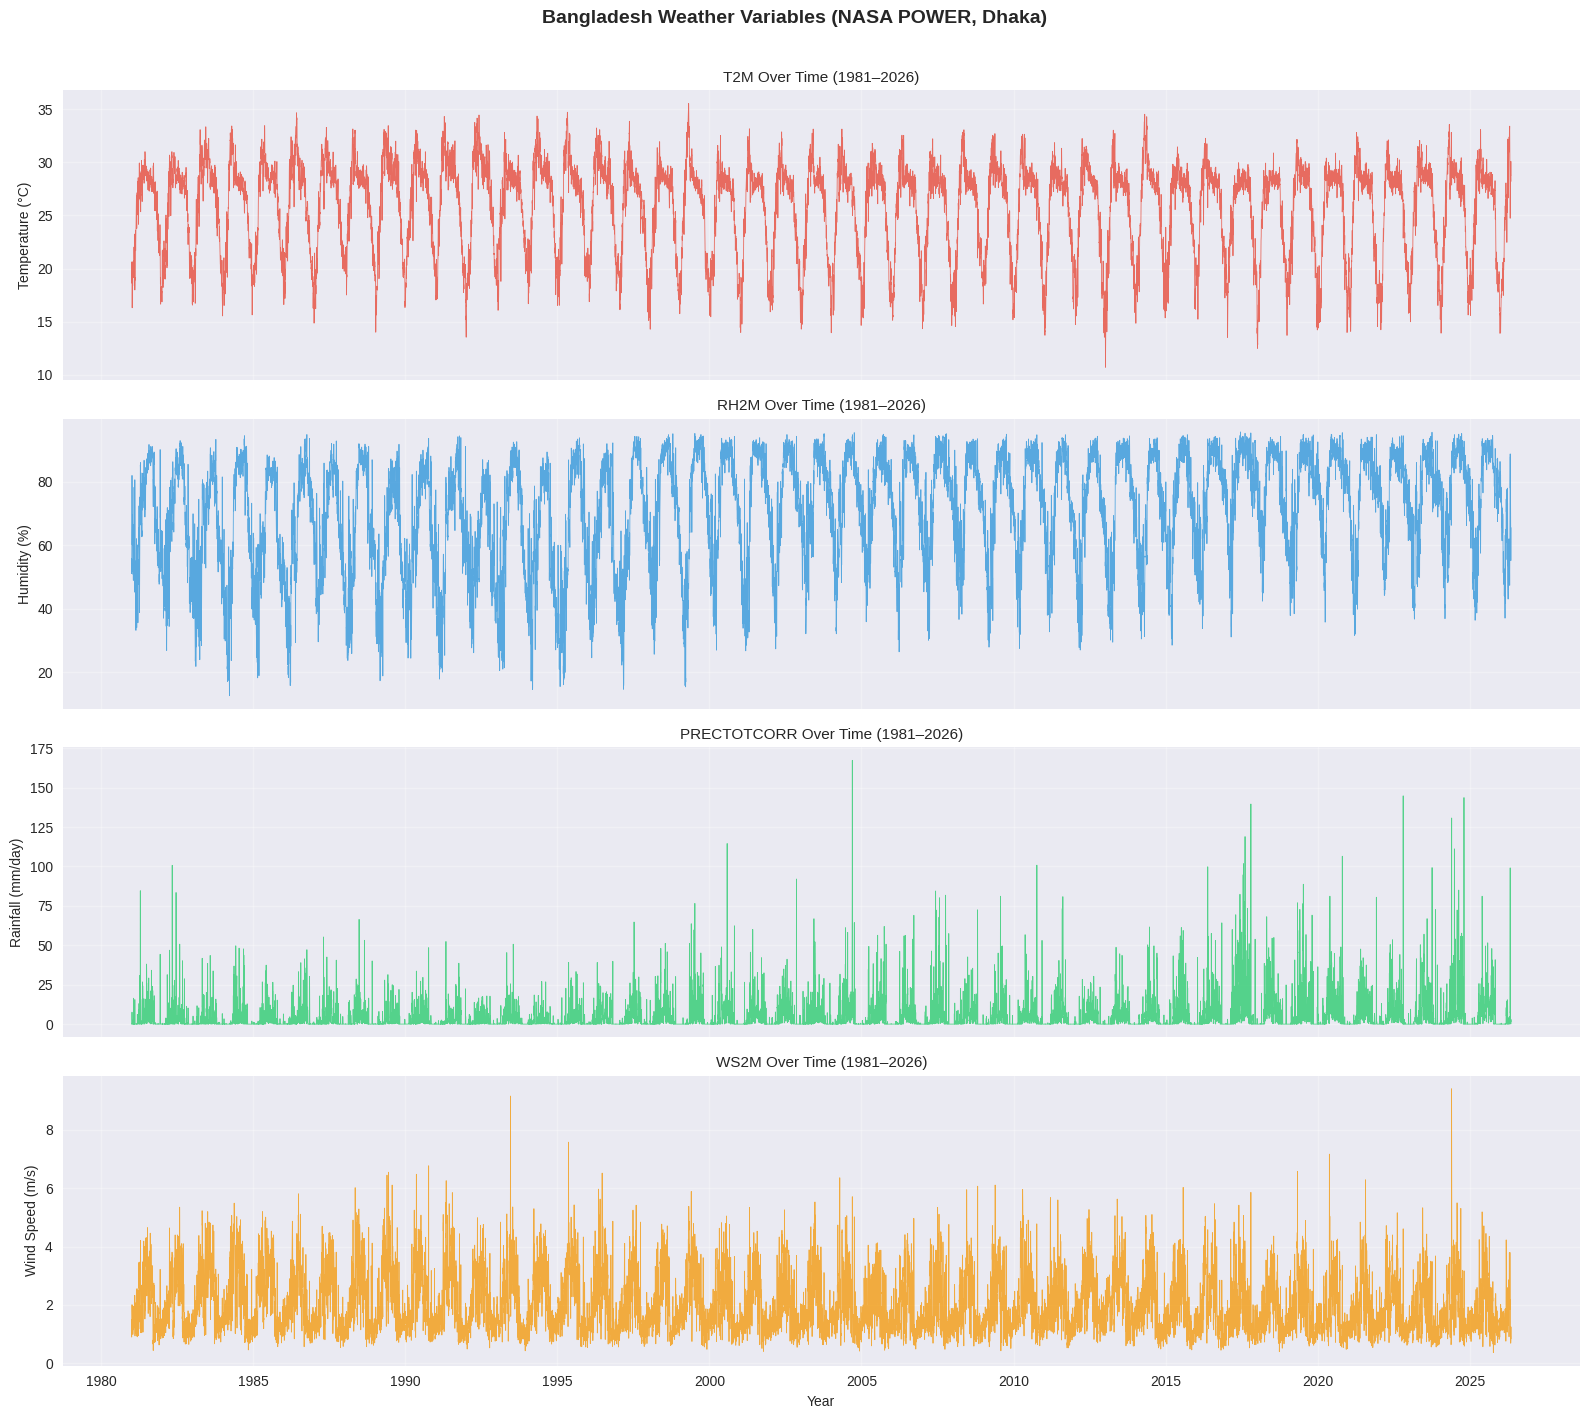

✅ Time series plot saved!


In [5]:
weather_vars = ['T2M', 'RH2M', 'PRECTOTCORR', 'WS2M']
labels = ['Temperature (°C)', 'Humidity (%)', 'Rainfall (mm/day)', 'Wind Speed (m/s)']
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True)
for i, (col, label, color) in enumerate(zip(weather_vars, labels, colors)):
    axes[i].plot(df['DATE'], df[col], linewidth=0.6, color=color, alpha=0.8)
    axes[i].set_ylabel(label, fontsize=10)
    axes[i].set_title(f'{col} Over Time (1981–2026)', fontsize=11)
    axes[i].grid(alpha=0.3)
axes[-1].set_xlabel('Year', fontsize=10)
plt.suptitle('Bangladesh Weather Variables (NASA POWER, Dhaka)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(SAVE_DIR + 'eda_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Time series plot saved!')

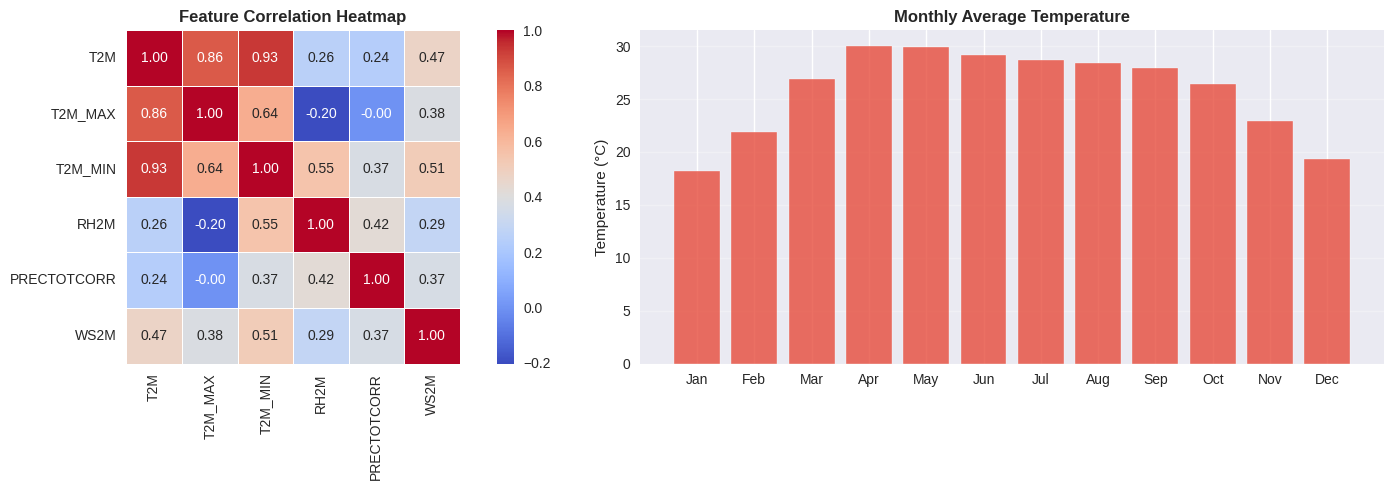

✅ Correlation plot saved!


In [6]:
corr_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'RH2M', 'PRECTOTCORR', 'WS2M']
df['MONTH'] = df['DATE'].dt.month
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f',
            square=True, ax=axes[0], linewidths=0.5)
axes[0].set_title('Feature Correlation Heatmap', fontsize=12, fontweight='bold')

monthly_avg = df.groupby('MONTH')['T2M'].mean()
axes[1].bar(month_names, monthly_avg.values, color='#e74c3c', alpha=0.8, edgecolor='white')
axes[1].set_title('Monthly Average Temperature', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Temperature (°C)')
axes[1].grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(SAVE_DIR + 'eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Correlation plot saved!')

In [7]:
print('=' * 60)
print('DATASET STATISTICS')
print('=' * 60)
print(df[corr_cols].describe().round(2))

DATASET STATISTICS
            T2M   T2M_MAX   T2M_MIN      RH2M  PRECTOTCORR      WS2M
count  16567.00  16567.00  16567.00  16567.00     16567.00  16567.00
mean      25.81     31.20     21.19     70.78         4.99      2.03
std        4.33      3.94      5.45     17.56         9.95      1.01
min       10.71     16.38      3.43     12.55         0.00      0.37
25%       22.55     28.76     16.44     58.23         0.00      1.25
50%       27.51     31.22     23.66     75.02         0.69      1.73
75%       28.84     33.34     25.84     85.99         5.85      2.70
max       35.52     44.47     29.42     95.77       167.28      9.41


## 🔧 Step 5: Feature Engineering (Multi-Target)

In [8]:
model_df = df.drop(columns=['YEAR', 'MO', 'DY', 'MONTH']).copy()
numeric_cols = model_df.select_dtypes(include=[np.number]).columns
model_df[numeric_cols] = model_df[numeric_cols].fillna(model_df[numeric_cols].mean())

# Multi-target: next day all 6 variables
feature_cols  = ['T2M', 'T2M_MAX', 'T2M_MIN', 'RH2M', 'PRECTOTCORR', 'WS2M']
target_cols   = feature_cols
target_pred_cols = [f'TARGET_{c}' for c in target_cols]

for col in target_cols:
    model_df[f'TARGET_{col}'] = model_df[col].shift(-1)

model_df = model_df.dropna(subset=target_pred_cols).reset_index(drop=True)

X = model_df[feature_cols].values
y = model_df[target_pred_cols].values

scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

split_idx = int(len(X_scaled) * 0.8)
X_train, X_test = X_scaled[:split_idx], X_scaled[split_idx:]
y_train, y_test = y_scaled[:split_idx], y_scaled[split_idx:]
y_train_raw, y_test_raw = y[:split_idx], y[split_idx:]

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test,  dtype=torch.float32)

print(f'Features : {feature_cols}')
print(f'Targets  : {target_pred_cols}')
print(f'X_train  : {X_train_t.shape}')
print(f'y_train  : {y_train_t.shape}')
print(f'X_test   : {X_test_t.shape}')
print(f'y_test   : {y_test_t.shape}')

Features : ['T2M', 'T2M_MAX', 'T2M_MIN', 'RH2M', 'PRECTOTCORR', 'WS2M']
Targets  : ['TARGET_T2M', 'TARGET_T2M_MAX', 'TARGET_T2M_MIN', 'TARGET_RH2M', 'TARGET_PRECTOTCORR', 'TARGET_WS2M']
X_train  : torch.Size([13255, 6])
y_train  : torch.Size([13255, 6])
X_test   : torch.Size([3314, 6])
y_test   : torch.Size([3314, 6])


## ⚛️ Step 6: QML Model (Hybrid VQC + Classical)

In [9]:
n_qubits = 6
n_layers = 3
dev = qml.device('lightning.qubit', wires=n_qubits)

@qml.qnode(dev, interface='torch')
def quantum_circuit(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(n_qubits))
    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

weight_shapes = {'weights': (n_layers, n_qubits, 3)}
quantum_layer = qml.qnn.TorchLayer(quantum_circuit, weight_shapes)

class HybridQMLModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.quantum = quantum_layer
        self.fc1 = nn.Linear(n_qubits, 16)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(16, 6)

    def forward(self, x):
        q_out = self.quantum(x)
        out = self.relu(self.fc1(q_out))
        return self.fc2(out)

model_qml = HybridQMLModel()
total_params = sum(p.numel() for p in model_qml.parameters())
print(model_qml)
print(f'\nTotal parameters: {total_params}')
print(f'Qubits: {n_qubits}, Layers: {n_layers}')
print('✅ Hybrid QML Model ready!')

HybridQMLModel(
  (quantum): <Quantum Torch Layer: func=quantum_circuit>
  (fc1): Linear(in_features=6, out_features=16, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=16, out_features=6, bias=True)
)

Total parameters: 268
Qubits: 6, Layers: 3
✅ Hybrid QML Model ready!


## 🏋️ Step 7: Train QML Model

In [10]:
def train_model(model, X_tr, y_tr, epochs=100, batch_size=64, lr=0.005):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5)
    loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=batch_size, shuffle=False)
    losses = []
    start = time.time()
    pbar = tqdm(range(1, epochs+1), desc='Training QML', ncols=80)
    for epoch in pbar:
        model.train()
        epoch_loss = 0.0
        for X_b, y_b in loader:
            optimizer.zero_grad()
            loss = criterion(model(X_b), y_b)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        avg = epoch_loss / len(loader)
        losses.append(avg)
        scheduler.step()
        pbar.set_postfix({'Loss': f'{avg:.4f}'})
        if epoch % 10 == 0:
            tqdm.write(f'Epoch [{epoch:3d}/{epochs}] Loss: {avg:.6f}')
    elapsed = time.time() - start
    print(f'\n✅ Training complete! Time: {elapsed/60:.1f} min | Final loss: {losses[-1]:.6f}')
    return losses, elapsed

qml_losses, qml_time = train_model(model_qml, X_train_t, y_train_t)

Training QML:  10%|█▏          | 10/100 [29:09<4:24:00, 176.00s/it, Loss=0.0026]

Epoch [ 10/100] Loss: 0.002573


Training QML:  20%|██▍         | 20/100 [59:09<4:01:52, 181.40s/it, Loss=0.0025]

Epoch [ 20/100] Loss: 0.002472


Training QML:  30%|███       | 30/100 [1:29:02<3:29:09, 179.28s/it, Loss=0.0024]

...

Epoch [ 80/100] Loss: 0.002258


Training QML:  90%|██████████▊ | 90/100 [4:30:26<30:23, 182.40s/it, Loss=0.0023]

Epoch [ 90/100] Loss: 0.002255


Training QML: 100%|███████████| 100/100 [5:00:30<00:00, 180.31s/it, Loss=0.0022]

Epoch [100/100] Loss: 0.002240

✅ Training complete! Time: 300.5 min | Final loss: 0.002240


## 🤖 Step 8: Baseline Models (LR, RF, MLP, LSTM)

In [11]:
# ── Linear Regression ──
print('Training Linear Regression...')
t0 = time.time()
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_time = time.time() - t0
print(f'✅ LR done in {lr_time:.1f}s')

# ── Random Forest ──
print('Training Random Forest...')
t0 = time.time()
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_time = time.time() - t0
print(f'✅ RF done in {rf_time:.1f}s')

Training Linear Regression...
✅ LR done in 0.1s
Training Random Forest...
✅ RF done in 10.8s


In [12]:
# ── MLP (Classical Neural Network) ──
class MLPModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(6, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 6)
        )
    def forward(self, x):
        return self.net(x)

model_mlp = MLPModel()
print('Training MLP...')
mlp_losses, mlp_time = train_model(model_mlp, X_train_t, y_train_t, epochs=100, lr=0.01)

Training MLP...


Training QML:  10%|█▌             | 10/100 [00:03<00:32,  2.81it/s, Loss=0.0030]

Epoch [ 10/100] Loss: 0.002956


Training QML:  20%|███            | 20/100 [00:07<00:29,  2.75it/s, Loss=0.0027]

Epoch [ 20/100] Loss: 0.002723


...

Epoch [ 80/100] Loss: 0.002216


Training QML:  90%|█████████████▌ | 90/100 [00:36<00:03,  2.68it/s, Loss=0.0022]

Epoch [ 90/100] Loss: 0.002211


Training QML: 100%|██████████████| 100/100 [00:41<00:00,  2.41it/s, Loss=0.0022]

Epoch [100/100] Loss: 0.002167

✅ Training complete! Time: 0.7 min | Final loss: 0.002167


In [13]:
# ── LSTM ──
class LSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(input_size=6, hidden_size=64, num_layers=2,
                            batch_first=True, dropout=0.2)
        self.fc = nn.Linear(64, 6)
    def forward(self, x):
        # x: (batch, 6) → (batch, 1, 6)
        x = x.unsqueeze(1)
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

model_lstm = LSTMModel()
print('Training LSTM...')
lstm_losses, lstm_time = train_model(model_lstm, X_train_t, y_train_t, epochs=100, lr=0.005)

Training LSTM...


Training QML:  10%|█▌             | 10/100 [00:11<01:33,  1.04s/it, Loss=0.0029]

Epoch [ 10/100] Loss: 0.002921


Training QML:  20%|███            | 20/100 [00:22<01:25,  1.07s/it, Loss=0.0028]

Epoch [ 20/100] Loss: 0.002835


...

Epoch [ 80/100] Loss: 0.002360


Training QML:  90%|█████████████▌ | 90/100 [01:44<00:11,  1.13s/it, Loss=0.0024]

Epoch [ 90/100] Loss: 0.002368


Training QML: 100%|██████████████| 100/100 [01:56<00:00,  1.16s/it, Loss=0.0023]

Epoch [100/100] Loss: 0.002320

✅ Training complete! Time: 1.9 min | Final loss: 0.002320


## 📈 Step 9: Evaluation — All Models

In [14]:
var_names = ['T2M', 'T2M_MAX', 'T2M_MIN', 'RH2M', 'PRECTOTCORR', 'WS2M']
units     = ['°C',  '°C',      '°C',      '%',    'mm/day',       'm/s']

def mape(y_true, y_pred):
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def evaluate_model(name, y_true, y_pred):
    rows = []
    for i, (var, unit) in enumerate(zip(var_names, units)):
        mae  = mean_absolute_error(y_true[:, i], y_pred[:, i])
        rmse = np.sqrt(mean_squared_error(y_true[:, i], y_pred[:, i]))
        r2   = r2_score(y_true[:, i], y_pred[:, i])
        mape_val = mape(y_true[:, i], y_pred[:, i])
        rows.append({'Model': name, 'Variable': var, 'Unit': unit,
                     'MAE': round(mae,4), 'RMSE': round(rmse,4),
                     'R2': round(r2,4), 'MAPE': round(mape_val,2)})
    return rows

# Predictions
def torch_predict(model, X_t):
    model.eval()
    with torch.no_grad():
        return scaler_y.inverse_transform(model(X_t).numpy())

y_pred_lr   = scaler_y.inverse_transform(lr_model.predict(X_test))
y_pred_rf   = scaler_y.inverse_transform(rf_model.predict(X_test))
y_pred_mlp  = torch_predict(model_mlp, X_test_t)
y_pred_lstm = torch_predict(model_lstm, X_test_t)
y_pred_qml  = torch_predict(model_qml, X_test_t)
y_true      = y_test_raw

all_rows = []
for name, pred in [('Linear Regression', y_pred_lr),
                   ('Random Forest',     y_pred_rf),
                   ('MLP',               y_pred_mlp),
                   ('LSTM',              y_pred_lstm),
                   ('QML (Ours)',         y_pred_qml)]:
    all_rows.extend(evaluate_model(name, y_true, pred))

eval_df = pd.DataFrame(all_rows)
eval_df.to_csv(SAVE_DIR + 'full_evaluation_results.csv', index=False)

print('=' * 80)
print('FULL MULTI-TARGET EVALUATION RESULTS')
print('=' * 80)
print(eval_df.to_string(index=False))
print('\n✅ Results saved!')

FULL MULTI-TARGET EVALUATION RESULTS
            Model    Variable   Unit    MAE    RMSE     R2    MAPE
Linear Regression         T2M     °C 0.5681  0.7579 0.9710    2.39
Linear Regression     T2M_MAX     °C 0.8686  1.1652 0.9110    2.91
Linear Regression     T2M_MIN     °C 0.6101  0.8459 0.9765    3.56
Linear Regression        RH2M      % 3.1870  4.4137 0.8954    4.53
Linear Regression PRECTOTCORR mm/day 5.1093 11.0501 0.3633  626.47
Linear Regression        WS2M    m/s 0.3994  0.5672 0.6097   24.84
    Random Forest         T2M     °C 0.5957  0.7833 0.9690    2.51
    Random Forest     T2M_MAX     °C 0.9112  1.2149 0.9033    3.09
    Random Forest     T2M_MIN     °C 0.5858  0.8001 0.9789    3.32
    Random Forest        RH2M      % 3.3402  4.6370 0.8845    4.75
    Random Forest PRECTOTCORR mm/day 5.1455 10.9447 0.3754  591.19
    Random Forest        WS2M    m/s 0.4118  0.5797 0.5924   26.26
              MLP         T2M     °C 0.5814  0.7511 0.9715    2.41
              MLP     T2M

In [15]:
# Summary table (average across all variables)
summary = eval_df.groupby('Model')[['MAE','RMSE','R2','MAPE']].mean().round(4)
summary = summary.reindex(['Linear Regression','Random Forest','MLP','LSTM','QML (Ours)'])
summary.columns = ['MAE (avg)', 'RMSE (avg)', 'R² (avg)', 'MAPE (avg %)']

print('=' * 60)
print('      MODEL COMPARISON SUMMARY (Average across 6 variables)')
print('=' * 60)
print(summary.to_string())
print('=' * 60)
summary.to_csv(SAVE_DIR + 'model_comparison_summary.csv')

      MODEL COMPARISON SUMMARY (Average across 6 variables)
                   MAE (avg)  RMSE (avg)  R² (avg)  MAPE (avg %)
Model                                                           
Linear Regression     1.7904      3.1333    0.7878      110.7833
Random Forest         1.8317      3.1599    0.7839      105.1867
MLP                   1.8191      3.0333    0.8001      156.2150
LSTM                  1.7915      3.0196    0.8016      157.6617
QML (Ours)            1.8589      3.0628    0.7970      190.8983


## 📉 Step 10: Convergence Plot (All Neural Models)

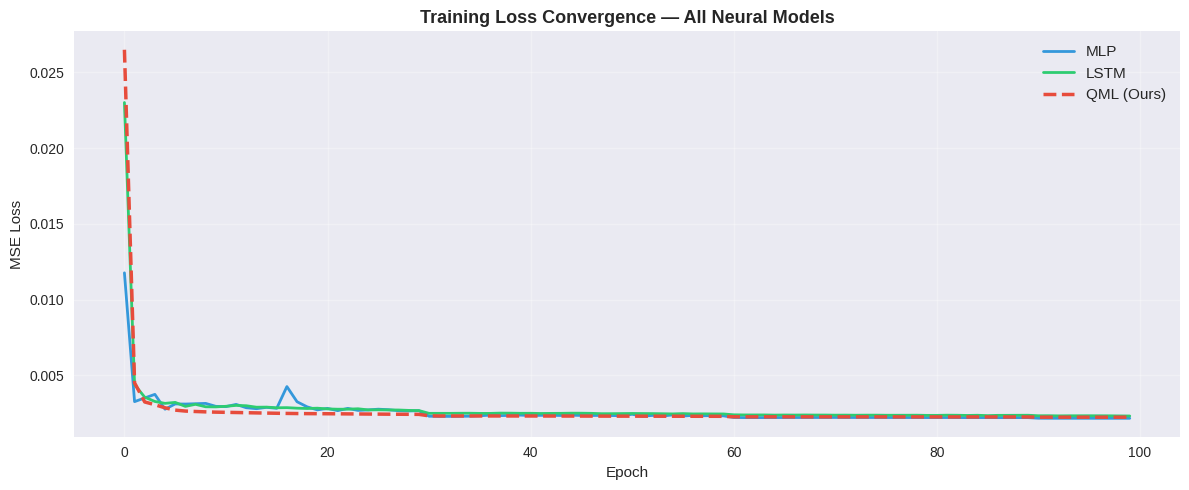

✅ Convergence plot saved!


In [16]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(mlp_losses,  label='MLP',      color='#3498db', linewidth=2)
ax.plot(lstm_losses, label='LSTM',     color='#2ecc71', linewidth=2)
ax.plot(qml_losses,  label='QML (Ours)', color='#e74c3c', linewidth=2.5, linestyle='--')
ax.set_title('Training Loss Convergence — All Neural Models', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(SAVE_DIR + 'convergence_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Convergence plot saved!')

## 🌡️ Step 11: Actual vs Predicted (T2M)

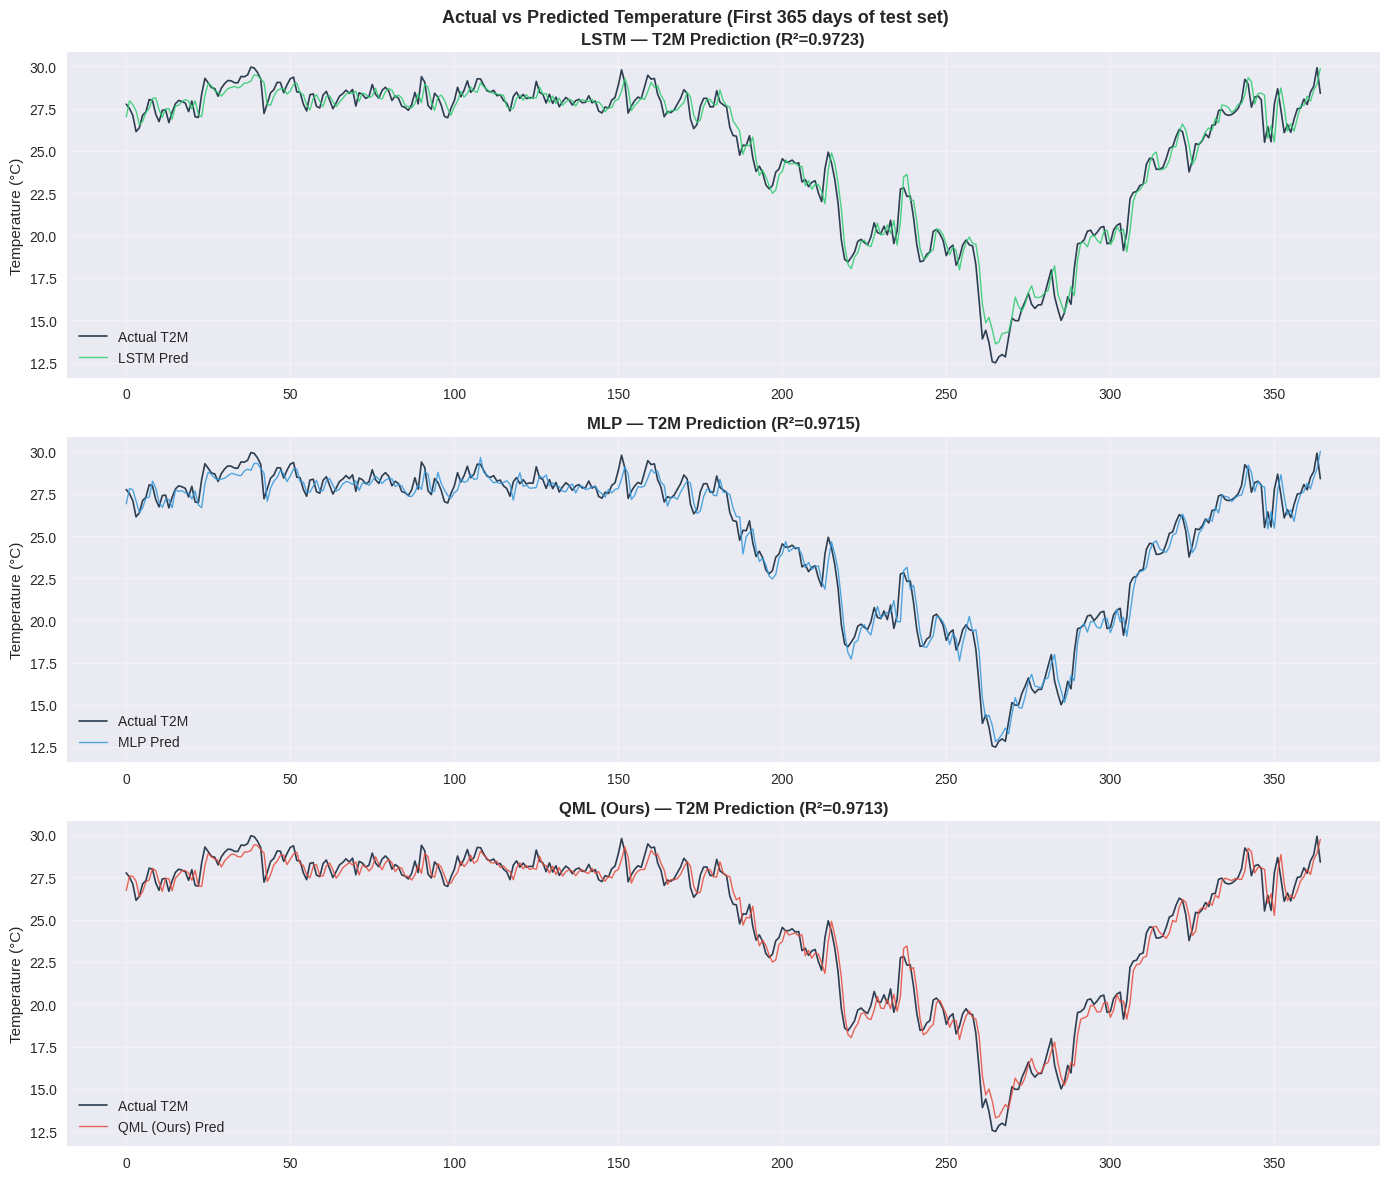

✅ Actual vs Predicted plot saved!


In [17]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
plot_n = 365  # show 1 year

for ax, (name, pred, color) in zip(axes, [
    ('LSTM',     y_pred_lstm, '#2ecc71'),
    ('MLP',      y_pred_mlp,  '#3498db'),
    ('QML (Ours)', y_pred_qml, '#e74c3c')
]):
    ax.plot(y_true[:plot_n, 0], label='Actual T2M',   color='#2c3e50', linewidth=1.2)
    ax.plot(pred[:plot_n, 0],   label=f'{name} Pred', color=color,     linewidth=1.0, alpha=0.85)
    r2 = r2_score(y_true[:, 0], pred[:, 0])
    ax.set_title(f'{name} — T2M Prediction (R²={r2:.4f})', fontweight='bold')
    ax.set_ylabel('Temperature (°C)')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('Actual vs Predicted Temperature (First 365 days of test set)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR + 'actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Actual vs Predicted plot saved!')

## 🔲 Step 12: Confusion Matrix (Temperature Categories)

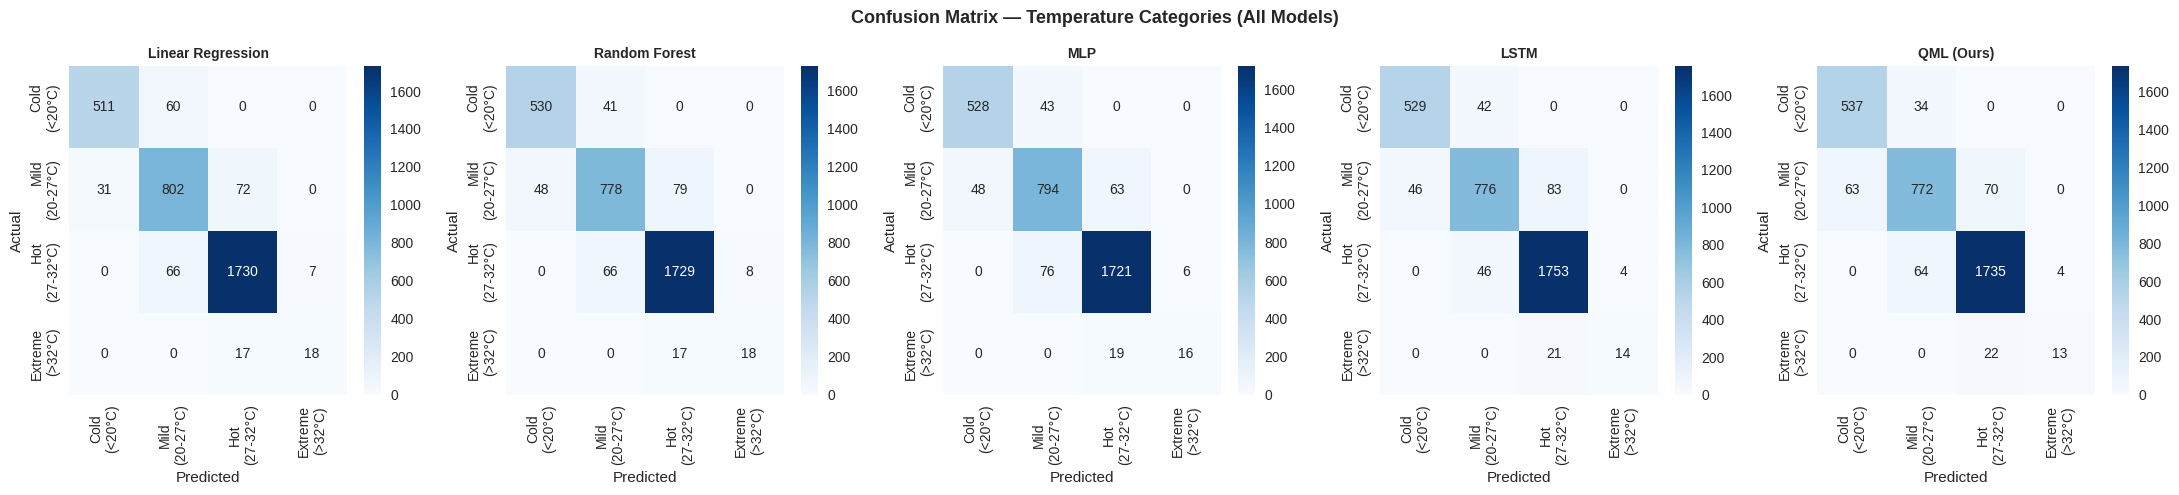

✅ Confusion matrix saved!


In [18]:
def categorize_temp(t):
    if t < 20:   return 0  # Cold
    elif t < 27: return 1  # Mild
    elif t < 32: return 2  # Hot
    else:        return 3  # Extreme

class_names = ['Cold\n(<20°C)', 'Mild\n(20-27°C)', 'Hot\n(27-32°C)', 'Extreme\n(>32°C)']

y_cat_true = np.array([categorize_temp(t) for t in y_true[:, 0]])

models_pred = {
    'Linear Regression': y_pred_lr,
    'Random Forest':     y_pred_rf,
    'MLP':               y_pred_mlp,
    'LSTM':              y_pred_lstm,
    'QML (Ours)':        y_pred_qml
}

fig, axes = plt.subplots(1, 5, figsize=(22, 5))
for ax, (name, pred) in zip(axes, models_pred.items()):
    y_cat_pred = np.array([categorize_temp(t) for t in pred[:, 0]])
    cm = confusion_matrix(y_cat_true, y_cat_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=class_names, yticklabels=class_names)
    ax.set_title(name, fontweight='bold', fontsize=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrix — Temperature Categories (All Models)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR + 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Confusion matrix saved!')

In [19]:
# Classification report for QML
y_cat_pred_qml = np.array([categorize_temp(t) for t in y_pred_qml[:, 0]])
print('QML Classification Report (Temperature Categories):')
print('=' * 55)
print(classification_report(y_cat_true, y_cat_pred_qml,
                             target_names=['Cold','Mild','Hot','Extreme']))

QML Classification Report (Temperature Categories):
              precision    recall  f1-score   support

        Cold       0.90      0.94      0.92       571
        Mild       0.89      0.85      0.87       905
         Hot       0.95      0.96      0.96      1803
     Extreme       0.76      0.37      0.50        35

    accuracy                           0.92      3314
   macro avg       0.87      0.78      0.81      3314
weighted avg       0.92      0.92      0.92      3314



## 📐 Step 13: ROC Curve (Multi-class)

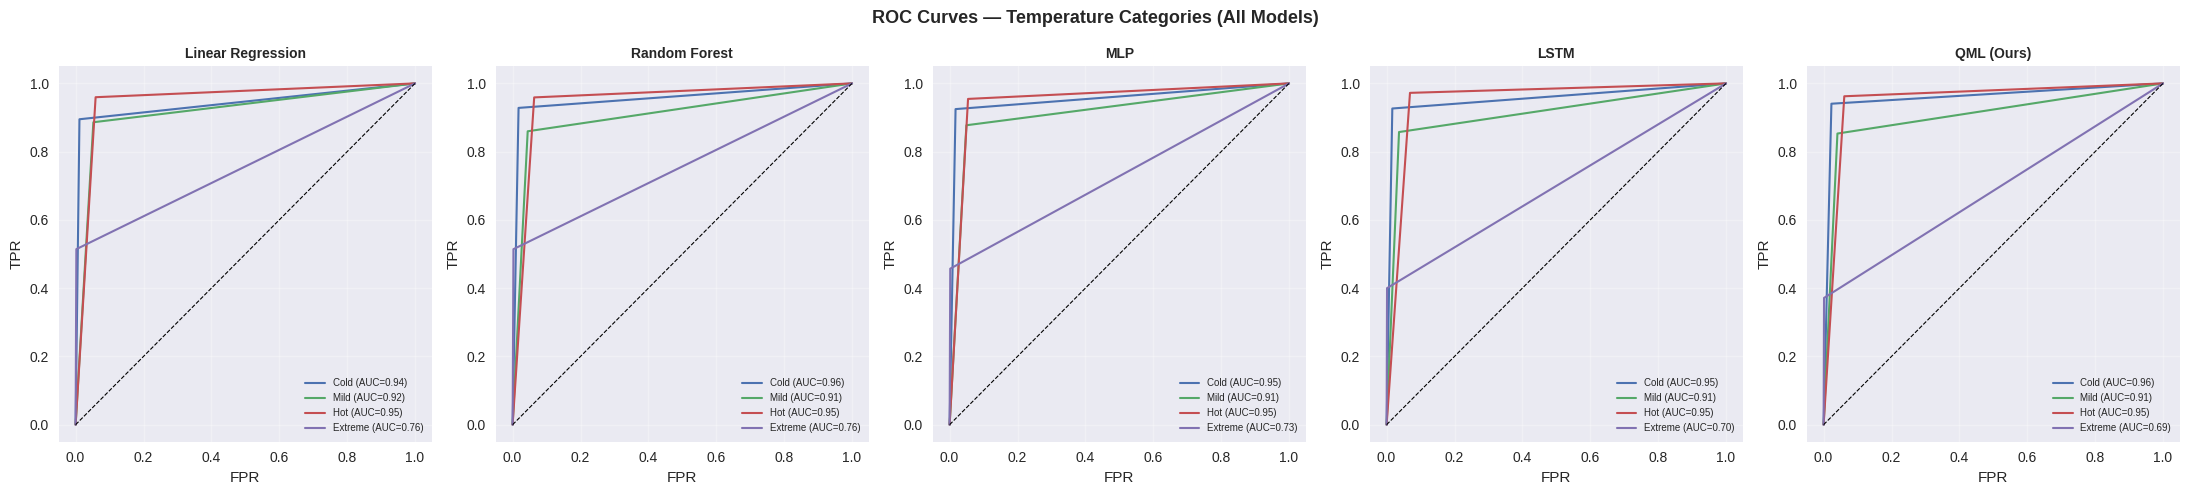

✅ ROC curves saved!


In [20]:
n_classes = 4
y_bin = label_binarize(y_cat_true, classes=[0,1,2,3])
colors_roc = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6']
cat_names  = ['Cold','Mild','Hot','Extreme']

fig, axes = plt.subplots(1, 5, figsize=(22, 5))

for ax, (name, pred), color in zip(axes, models_pred.items(), colors_roc):
    y_cat_p = np.array([categorize_temp(t) for t in pred[:, 0]])
    y_bin_p = label_binarize(y_cat_p, classes=[0,1,2,3])
    for i, cat in enumerate(cat_names):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_bin_p[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, linewidth=1.5, label=f'{cat} (AUC={roc_auc:.2f})')
    ax.plot([0,1],[0,1], 'k--', linewidth=0.8)
    ax.set_title(name, fontweight='bold', fontsize=10)
    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.suptitle('ROC Curves — Temperature Categories (All Models)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR + 'roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ ROC curves saved!')

## 📊 Step 14: Model Comparison Bar Chart

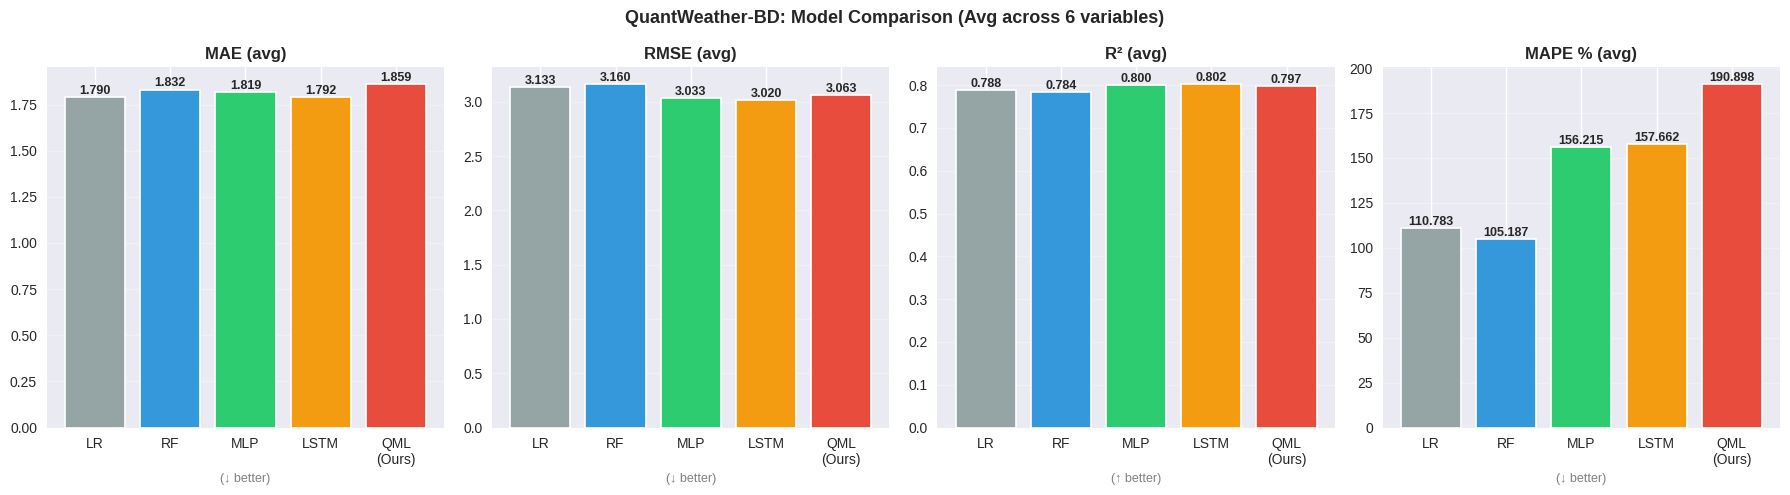

✅ Comparison chart saved!


In [21]:
model_names = ['LR', 'RF', 'MLP', 'LSTM', 'QML\n(Ours)']
bar_colors  = ['#95a5a6','#3498db','#2ecc71','#f39c12','#e74c3c']

mae_vals  = summary['MAE (avg)'].values
rmse_vals = summary['RMSE (avg)'].values
r2_vals   = summary['R² (avg)'].values
mape_vals = summary['MAPE (avg %)'].values

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, vals, title, better in zip(axes,
    [mae_vals, rmse_vals, r2_vals, mape_vals],
    ['MAE (avg)', 'RMSE (avg)', 'R² (avg)', 'MAPE % (avg)'],
    ['lower','lower','higher','lower']):
    bars = ax.bar(model_names, vals, color=bar_colors, edgecolor='white', linewidth=1.2)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3, axis='y')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.001,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_xlabel(f'(↓ better)' if better=='lower' else '(↑ better)', fontsize=9, color='gray')

plt.suptitle('QuantWeather-BD: Model Comparison (Avg across 6 variables)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR + 'model_comparison_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Comparison chart saved!')

## ⏱️ Step 15: Training Time Comparison

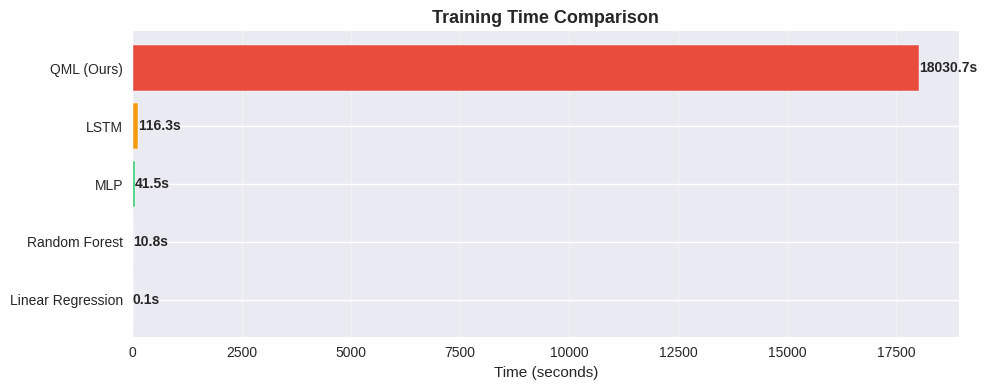

            Model  Training Time (s)
Linear Regression                0.1
    Random Forest               10.8
              MLP               41.5
             LSTM              116.3
       QML (Ours)            18030.7

✅ Training time plot saved!


In [22]:
time_data = {
    'Model': ['Linear Regression', 'Random Forest', 'MLP', 'LSTM', 'QML (Ours)'],
    'Training Time (s)': [round(lr_time,1), round(rf_time,1),
                          round(mlp_time,1), round(lstm_time,1), round(qml_time,1)]
}
time_df = pd.DataFrame(time_data)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(time_df['Model'], time_df['Training Time (s)'],
               color=['#95a5a6','#3498db','#2ecc71','#f39c12','#e74c3c'],
               edgecolor='white')
for bar, val in zip(bars, time_df['Training Time (s)']):
    ax.text(bar.get_width()+1, bar.get_y()+bar.get_height()/2,
            f'{val:.1f}s', va='center', fontsize=10, fontweight='bold')
ax.set_title('Training Time Comparison', fontsize=13, fontweight='bold')
ax.set_xlabel('Time (seconds)')
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(SAVE_DIR + 'training_time.png', dpi=150, bbox_inches='tight')
plt.show()

print(time_df.to_string(index=False))
print('\n✅ Training time plot saved!')

## 🔬 Step 16: Statistical Significance Test (Wilcoxon)

In [23]:
# Wilcoxon Signed-Rank Test: QML vs each baseline (T2M errors)
qml_errors  = np.abs(y_true[:, 0] - y_pred_qml[:, 0])
baseline_preds = {
    'Linear Regression': y_pred_lr,
    'Random Forest':     y_pred_rf,
    'MLP':               y_pred_mlp,
    'LSTM':              y_pred_lstm
}

print('=' * 60)
print('WILCOXON SIGNED-RANK TEST (QML vs Baselines)')
print('H0: No significant difference in prediction errors')
print('=' * 60)
sig_rows = []
for name, pred in baseline_preds.items():
    base_errors = np.abs(y_true[:, 0] - pred[:, 0])
    stat, p = stats.wilcoxon(qml_errors, base_errors)
    sig = '✅ Significant' if p < 0.05 else '❌ Not significant'
    print(f'QML vs {name:<20} | p={p:.6f} | {sig}')
    sig_rows.append({'Comparison': f'QML vs {name}', 'p-value': round(p, 6),
                     'Significant (p<0.05)': p < 0.05})
print('=' * 60)

sig_df = pd.DataFrame(sig_rows)
sig_df.to_csv(SAVE_DIR + 'statistical_tests.csv', index=False)
print('\n✅ Statistical test results saved!')

WILCOXON SIGNED-RANK TEST (QML vs Baselines)
H0: No significant difference in prediction errors
QML vs Linear Regression    | p=0.004393 | ✅ Significant
QML vs Random Forest        | p=0.029319 | ✅ Significant
QML vs MLP                  | p=0.696380 | ❌ Not significant
QML vs LSTM                 | p=0.000000 | ✅ Significant

✅ Statistical test results saved!


## 💾 Step 17: Save All Models

In [24]:
torch.save(model_qml.state_dict(),  SAVE_DIR + 'qml_model_final.pth')
torch.save(model_mlp.state_dict(),  SAVE_DIR + 'mlp_model_final.pth')
torch.save(model_lstm.state_dict(), SAVE_DIR + 'lstm_model_final.pth')
joblib.dump(lr_model,   SAVE_DIR + 'lr_model.pkl')
joblib.dump(rf_model,   SAVE_DIR + 'rf_model.pkl')
joblib.dump(scaler_X,   SAVE_DIR + 'scaler_X.pkl')
joblib.dump(scaler_y,   SAVE_DIR + 'scaler_y.pkl')

print('✅ All models saved!')
print('\nSaved files:')
for f in sorted(os.listdir(SAVE_DIR)):
    print(f'  📁 {f}')

✅ All models saved!

Saved files:
  📁 Dataset
  📁 QuantWeather.ipynb
  📁 actual_vs_predicted.png
  📁 confusion_matrix.png
  📁 convergence_plot.png
  📁 eda_correlation.png
  📁 eda_timeseries.png
  📁 full_evaluation_results.csv
  📁 lr_model.pkl
  📁 lstm_model_final.pth
  📁 mlp_model_final.pth
  📁 model_comparison_chart.png
  📁 model_comparison_summary.csv
  📁 qml_model_final.pth
  📁 rf_model.pkl
  📁 roc_curves.png
  📁 scaler_X.pkl
  📁 scaler_y.pkl
  📁 statistical_tests.csv
  📁 training_time.png


## 📋 Step 18: Final Summary

In [25]:
print('=' * 65)
print('         QUANTWEATHER-BD — FINAL SUMMARY')
print('=' * 65)
print(f'  Project      : QuantWeather-BD')
print(f'  Dataset      : NASA POWER, Dhaka, Bangladesh')
print(f'  Date Range   : 1981-01-01 → 2026-05-14')
print(f'  Total Samples: {len(df)}')
print(f'  Train/Test   : 80% / 20%')
print(f'  Features     : {feature_cols}')
print(f'  Targets      : 6 variables (next-day)')
print('-' * 65)
print(f'  QML Config   : {n_qubits} qubits, {n_layers} VQC layers')
print(f'  QML Params   : {sum(p.numel() for p in model_qml.parameters())}')
print('-' * 65)
print('  MODEL COMPARISON (Average across 6 variables):')
print(summary.to_string())
print('-' * 65)
print('  OUTPUT FILES:')
print('  📊 eda_timeseries.png')
print('  📊 eda_correlation.png')
print('  📊 convergence_plot.png')
print('  📊 actual_vs_predicted.png')
print('  📊 confusion_matrix.png')
print('  📊 roc_curves.png')
print('  📊 model_comparison_chart.png')
print('  📊 training_time.png')
print('  📄 full_evaluation_results.csv')
print('  📄 model_comparison_summary.csv')
print('  📄 statistical_tests.csv')
print('=' * 65)
print('  🎉 QuantWeather-BD Complete!')
print('=' * 65)

         QUANTWEATHER-BD — FINAL SUMMARY
  Project      : QuantWeather-BD
  Dataset      : NASA POWER, Dhaka, Bangladesh
  Date Range   : 1981-01-01 → 2026-05-14
  Total Samples: 16570
  Train/Test   : 80% / 20%
  Features     : ['T2M', 'T2M_MAX', 'T2M_MIN', 'RH2M', 'PRECTOTCORR', 'WS2M']
  Targets      : 6 variables (next-day)
-----------------------------------------------------------------
  QML Config   : 6 qubits, 3 VQC layers
  QML Params   : 268
-----------------------------------------------------------------
  MODEL COMPARISON (Average across 6 variables):
                   MAE (avg)  RMSE (avg)  R² (avg)  MAPE (avg %)
Model                                                           
Linear Regression     1.7904      3.1333    0.7878      110.7833
Random Forest         1.8317      3.1599    0.7839      105.1867
MLP                   1.8191      3.0333    0.8001      156.2150
LSTM                  1.7915      3.0196    0.8016      157.6617
QML (Ours)            1.8589      3.06